# REEDs PCA Baselines for Si & CdTe

ReEDS installation projections from the Solar Futures Study, published by DOE on 2021.

Scenario Interest: 
o	95-by-35+Elec.Adv+DR ,  a.k.a. "Solar Futures Decarbonization + Electrification scenario"

This code performs three Methods to output files for the Mass Flows:
<ol>
    <li> PCA original data by ReEDS </li>
    <li> PCA data reordered based on ascending production up to 2035, and then descending, </li>
    <li> PCA data calculated with an exponencial that mathces the cumulative 2035 and 2050 targets </li>
</ol>

In [2]:
import PV_ICE
import numpy as np
import pandas as pd
import os,sys
import matplotlib.pyplot as plt
import csv
import platform

plt.rcParams.update({'font.size': 22})
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
from pathlib import Path

cwd = os.getcwd()
testfolder = os.path.join(cwd, 'TEMP')

if not os.path.exists(testfolder):
    os.makedirs(testfolder)
print ("Your simulation will be stored in %s" % testfolder)


Your simulation will be stored in C:\Users\sayala\Documents\GitHub\public\PV_ICE\Studies\Julian_US_Reeds2024_PCA_EoL_ReliabilitySpread\TEMP


In [4]:
# This information helps with debugging and getting support :)
print("Working on a ", platform.system(), platform.release())
print("Python version ", sys.version)
print("Pandas version ", pd.__version__)
print("PV_ICE version ", PV_ICE.__version__)

baselinesFolder = Path().resolve().parent.parent.parent / 'PV_ICE' / 'PV_ICE' / 'baselines'
print("Baselines Folder"), baselinesFolder

Working on a  Windows 11
Python version  3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Pandas version  2.2.3
PV_ICE version  0.2.1.dev710+g684c1eea6.d20260402
Baselines Folder


(None,
 WindowsPath('C:/Users/sayala/Documents/GitHub/public/PV_ICE/PV_ICE/baselines'))

In [5]:
reedsFile = 'StdScen24_annual_balancingAreas.csv'
#os.path.join(baselinesFolder, 'SupportingMaterial', 'December Core Scenarios ReEDS Outputs Solar Futures v3a.xlsx')
print ("Input file is stored in %s" % reedsFile)


Input file is stored in StdScen24_annual_balancingAreas.csv


In [6]:
# load CSV using row 4 as the header
df = pd.read_csv(reedsFile, header=3)

# inspect columns if needed
print(df.columns.tolist())

# keep only Mid_Case rows
df_mid = df[df["scenario"] == "Mid_Case"].copy()

# keep just PCA region and the utility-scale PV column
REEDSInput = df_mid[["r", "upv_MW", "state", "t"]].copy()

['scenario', 'policy', 'r', 'state', 'country', 't', 'load_enduse_MWh', 'load_dist_loss_MWh', 'load_trans_loss_MWh', 'load_canada_exports_MWh', 'load_storage_charging_MWh', 'load_electrolyzer_MWh', 'load_dac_MWh', 'load_MWh', 'h2_produced_mt', 'battery_4_MW', 'battery_8_MW', 'bio_MW', 'bio-ccs_MW', 'coal_ccs_MW', 'coal_MW', 'csp_MW', 'distpv_MW', 'gas_cc_ccs_MW', 'gas_cc_MW', 'gas_ct_MW', 'geo_MW', 'hydro_MW', 'nuclear_MW', 'nuclear_smr_MW', 'o-g-s_MW', 'pumped-hydro_MW', 'h2-ct_MW', 'upv_MW', 'wind_offshore_MW', 'wind_onshore_MW', 'dac_MW', 'electrolyzer_MW', 'battery_4_MWh', 'battery_8_MWh', 'bio_MWh', 'bio-ccs_MWh', 'canada_MWh', 'coal_ccs_MWh', 'coal_MWh', 'csp_MWh', 'distpv_MWh', 'gas_cc_ccs_MWh', 'gas_cc_MWh', 'gas_ct_MWh', 'geo_MWh', 'hydro_MWh', 'nuclear_MWh', 'nuclear_smr_MWh', 'o-g-s_MWh', 'pumped-hydro_MWh', 'h2-ct_MWh', 'upv_MWh', 'wind_offshore_MWh', 'wind_onshore_MWh', 'generation', 'generation_for_aer', 'co2_c_mt', 'co2_c_net_mt', 'ch4_c_mt', 'n2o_c_mt', 'so2_c_mt', 'nox

In [7]:
REEDSInput

,r,upv_MW,state,t
53865,p1,15.313302,WA,2026
53866,p1,15.313302,WA,2029
53867,p1,15.313302,WA,2032
53868,p1,15.313302,WA,2035
53869,p1,15.313302,WA,2038
...,...,...,...,...
55057,p134,802.992621,ME,2038
55058,p134,802.992621,ME,2041
55059,p134,802.992621,ME,2044
55060,p134,802.992621,ME,2047


In [8]:
# =====================================================================================
# USER SETTINGS
# =====================================================================================

scenario_keep = "Mid_Case"   # already filtered upstream, here just for file naming
value_col = "upv_MW"         # ReEDS new installs, already in MW
region_col = "r"
year_col = "t"
state_col = "state"

sparkplot = True

In [9]:
# Regular increasing interval weights:
# 2-year block: 1/3, 2/3
# 3-year block: 1/6, 2/6, 3/6
weights_2yr = np.array([1, 2], dtype=float)
weights_2yr = weights_2yr / weights_2yr.sum()

weights_3yr = np.array([1, 2, 3], dtype=float)
weights_3yr = weights_3yr / weights_3yr.sum()

# Option 2: (Equal division
weights_2yr = np.array([1/2, 1/2])
weights_3yr = np.array([1/3, 1/3, 1/3])


In [10]:
# =====================================================================================
# INPUT CHECK / CLEAN REEDS DATA
# =====================================================================================

# REEDSInput must include year
# Example expected:
# REEDSInput = df_mid[["r", "year", "upv_MW", "state"]].copy()

rawdf = REEDSInput.copy()
rawdf.columns = rawdf.columns.str.strip()

required_cols = [region_col, year_col, value_col]
missing = [c for c in required_cols if c not in rawdf.columns]
if missing:
    raise ValueError(
        f"REEDSInput is missing required columns: {missing}. "
        f"It must include at least {required_cols}."
    )

rawdf[year_col] = pd.to_numeric(rawdf[year_col], errors="coerce").astype("Int64")
rawdf[value_col] = pd.to_numeric(rawdf[value_col], errors="coerce")
rawdf = rawdf.dropna(subset=[region_col, year_col, value_col]).copy()
rawdf[year_col] = rawdf[year_col].astype(int)

# one row per PCA-year preferred; if not, sum duplicates
reeds_pivot = rawdf.pivot_table(
    index=region_col,
    columns=year_col,
    values=value_col,
    aggfunc="sum"
).sort_index(axis=1)



In [11]:

# =====================================================================================
# FUNCTION: EXPAND COARSE-TIME-STEP INSTALLS TO ANNUAL INSTALLS
# =====================================================================================

def expand_reeds_to_annual_new_installs(series, weights_2yr, weights_3yr):
    """
    ReEDS series is assumed to contain NEW INSTALLS (not cumulative),
    reported at coarse time steps.

    Logic:
    - First reported year is kept as-is.
    - If next point is 2 years later, split that reported value across:
          [y-1, y] with weights [1/3, 2/3]
    - If next point is 3 years later, split that reported value across:
          [y-2, y-1, y] with weights [1/6, 2/6, 3/6]
    - If step is 1 year, keep as-is
    - If some other step appears, split across the interval with linearly
      increasing weights [1, 2, ..., step]

    Example:
      2020 = 120, 2023 = 60
    then 2023's 60 gets distributed across 2021, 2022, 2023 as:
      10, 20, 30
    """
    s = series.dropna().sort_index()
    if len(s) == 0:
        return pd.Series(dtype=float)

    annual = {}

    years = list(s.index)
    vals = list(s.values)

    # first point: keep as-is
    annual[years[0]] = float(vals[0])

    for i in range(1, len(years)):
        y_prev = years[i - 1]
        y_curr = years[i]
        v_curr = float(vals[i])
        step = y_curr - y_prev

        if step == 1:
            annual[y_curr] = annual.get(y_curr, 0.0) + v_curr

        elif step == 2:
            split_vals = v_curr * weights_2yr
            block_years = [y_curr - 1, y_curr]
            for yy, vv in zip(block_years, split_vals):
                annual[yy] = annual.get(yy, 0.0) + vv

        elif step == 3:
            split_vals = v_curr * weights_3yr
            block_years = [y_curr - 2, y_curr - 1, y_curr]
            for yy, vv in zip(block_years, split_vals):
                annual[yy] = annual.get(yy, 0.0) + vv

        else:
            # fallback for any other gap
            weights = np.arange(1, step + 1, dtype=float)
            weights = weights / weights.sum()
            split_vals = v_curr * weights
            block_years = list(range(y_curr - step + 1, y_curr + 1))
            for yy, vv in zip(block_years, split_vals):
                annual[yy] = annual.get(yy, 0.0) + vv

    out = pd.Series(annual).sort_index()
    out.index = out.index.astype(int)
    out.name = "new_Installed_Capacity_[MW]"
    return out

In [12]:
r1 = PV_ICE.Simulation(name='Simulation1', path=testfolder)

# cSi baseline
r1.createScenario(
    name='Si',
    massmodulefile='baseline_modules_mass_US_Si.csv',
    energymodulefile='baseline_modules_energy_Si.csv'
)

path = C:\Users\sayala\Documents\GitHub\public\PV_ICE\Studies\Julian_US_Reeds2024_PCA_EoL_ReliabilitySpread\TEMP
Baseline folder directed to default:  C:\Users\sayala\Documents\GitHub\public\PV_ICE\PV_ICE\baselines


In [13]:
# =====================================================================================
# LOAD PV ICE BASELINES
# =====================================================================================


baseline_Si = r1.scenario['Si'].dataIn_m.copy()
baseline_Si = baseline_Si.drop(columns=['new_Installed_Capacity_[MW]'])
baseline_Si.set_index('year', inplace=True)
baseline_Si.index = baseline_Si.index.astype(int)

# CdTe baseline
r1.createScenario(
    name='CdTe',
    massmodulefile='baseline_modules_mass_US_CdTe.csv',
    energymodulefile='baseline_modules_energy_CdTe.csv'
)
baseline_cdte = r1.scenario['CdTe'].dataIn_m.copy()
baseline_cdte = baseline_cdte.drop(columns=['new_Installed_Capacity_[MW]'])
baseline_cdte.set_index('year', inplace=True)
baseline_cdte.index = baseline_cdte.index.astype(int)


In [14]:
# =====================================================================================
# READ THE TWO HEADER ROWS FROM THE BASELINE FILE
# =====================================================================================

massmodulefile = os.path.join(baselinesFolder, 'baseline_modules_mass_US_Si.csv')

with open(massmodulefile, newline='') as f:
    reader = csv.reader(f)
    row1 = next(reader)
    row2 = next(reader)

row11 = 'year,' + ','.join(row1[1:])
row22 = 'year,' + ','.join(row2[1:])
header_text = row11 + '\n' + row22 + '\n'

In [15]:
# =====================================================================================
# LOAD MARKET SHARE
# =====================================================================================

marketsharefile = os.path.join(
    baselinesFolder,
    'SupportingMaterial',
    'output_USA_Si_marketshare.csv'
)

marketshare = pd.read_csv(marketsharefile)
marketshare = marketshare[marketshare['Year'] >= 2010].reset_index(drop=True)
marketshare.set_index('Year', inplace=True)
marketshare.index = marketshare.index.astype(int)

marketshare.rename(columns={'All_Marketshare': 'Si Market Share'}, inplace=True)
marketshare.loc[2021:, 'Si Market Share'] = 0.81
marketshare['CdTe Market Share'] = 1 - marketshare['Si Market Share']


In [16]:
# =====================================================================================
# OUTPUT FOLDERS
# =====================================================================================

subtestfolder = os.path.join(testfolder, 'PCAs_Method1')
os.makedirs(subtestfolder, exist_ok=True)


if sparkplot:
    sparkplotfolder = os.path.join(subtestfolder, 'SPARKPLOTS')
    os.makedirs(sparkplotfolder, exist_ok=True)

KeyboardInterrupt: 

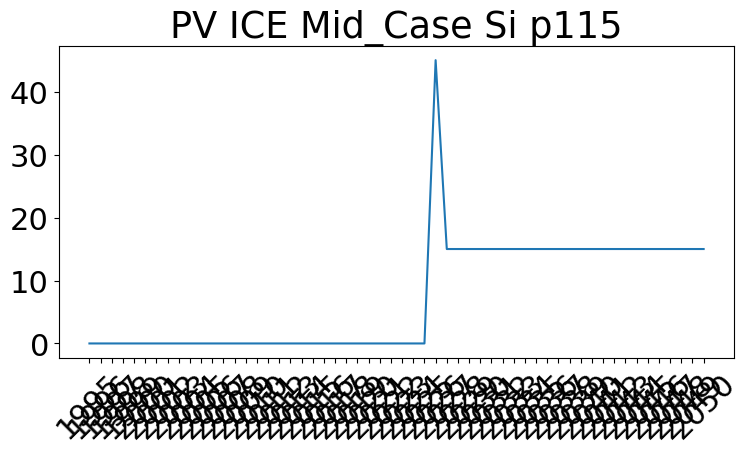

In [16]:
# =====================================================================================
# MAIN LOOP: ONE PCA AT A TIME
# =====================================================================================

for PCA in reeds_pivot.index:

    # sparse ReEDS new installs for this PCA
    reeds_series = reeds_pivot.loc[PCA].dropna().sort_index()

    # expand coarse time-step values to annual values
    annual_series = expand_reeds_to_annual_new_installs(
        reeds_series,
        weights_2yr=weights_2yr,
        weights_3yr=weights_3yr
    )

    # align to PV ICE baseline years
    target_years = baseline_Si.index
    annual_series = annual_series.reindex(target_years, fill_value=0.0)

    # align market share to same years
    ms = marketshare.reindex(target_years).copy()
    ms['Si Market Share'] = ms['Si Market Share'].ffill().fillna(0.81)
    ms['CdTe Market Share'] = ms['CdTe Market Share'].ffill().fillna(0.19)

    # split installs by technology
    si_installs = annual_series * ms['Si Market Share']
    cdte_installs = annual_series * ms['CdTe Market Share']

    # ----------------------------
    # BUILD Si PV ICE INPUT FILE
    # ----------------------------
    B_Si = baseline_Si.reindex(target_years).copy()
    B_Si.insert(0, 'new_Installed_Capacity_[MW]', si_installs.values)
    B_Si.index.name = 'year'

    filetitle_si = os.path.join(subtestfolder, f"{scenario_keep}_Si_{PCA}.csv")
    with open(filetitle_si, 'w', newline='') as ict:
        ict.write(header_text)
        B_Si.to_csv(ict, header=False)

    # ----------------------------
    # BUILD CdTe PV ICE INPUT FILE
    # ----------------------------
    B_cdte = baseline_cdte.reindex(target_years).copy()
    B_cdte.insert(0, 'new_Installed_Capacity_[MW]', cdte_installs.values)
    B_cdte.index.name = 'year'

    filetitle_cdte = os.path.join(subtestfolder, f"{scenario_keep}_CdTe_{PCA}.csv")
    with open(filetitle_cdte, 'w', newline='') as ict:
        ict.write(header_text)
        B_cdte.to_csv(ict, header=False)

    # ----------------------------
    # OPTIONAL SPARKPLOT
    # ----------------------------
    if sparkplot:
        fig, ax = plt.subplots(figsize=(8, 5), facecolor='w', edgecolor='k')
        ax.plot(B_Si.index.astype(str), B_Si['new_Installed_Capacity_[MW]'].values)
        ax.set_title(f'PV ICE {scenario_keep} Si {PCA}')
        ax.tick_params(axis='x', rotation=45)
        fig.tight_layout()
        fig.savefig(
            os.path.join(sparkplotfolder, f'PV_ICE_{scenario_keep}_Si_{PCA}.png'),
            dpi=300
        )
        plt.close(fig)

print("Results saved in:", subtestfolder)

# INTEGRATING PREVIOUS HISTORIC REEDS

In [17]:
REEDSInput_new = REEDSInput.copy()
REEDSInput_new

,r,upv_MW,state,t
53865,p1,15.313302,WA,2026
53866,p1,15.313302,WA,2029
53867,p1,15.313302,WA,2032
53868,p1,15.313302,WA,2035
53869,p1,15.313302,WA,2038
...,...,...,...,...
55057,p134,802.992621,ME,2038
55058,p134,802.992621,ME,2041
55059,p134,802.992621,ME,2044
55060,p134,802.992621,ME,2047


In [18]:
old_reedsFile =os.path.join(baselinesFolder, 'SupportingMaterial', 'December Core Scenarios ReEDS Outputs Solar Futures v3a.xlsx')   # old Excel file
old_sheet = "new installs PV"                    # old sheet name

REEDSInput_old = pd.read_excel(old_reedsFile,
#                        sheet_name="new installs PV (2)")
                       sheet_name="new installs PV")

#index_col=[0,2,3]) #this casts scenario, PCA and State as levels

In [19]:
rawdf_old = REEDSInput_old.copy()
rawdf_old.drop(columns=['State'], inplace=True)
rawdf_old.drop(columns=['Tech'], inplace=True)
rawdf_old.set_index(['Scenario', 'Year', 'PCA'], inplace=True)

In [20]:
rawdf_old

Capacity (GW)
Scenario      Year PCA               
95-by-35.Adv  2010 p1        0.000017
              2011 p1        0.005158
              2012 p1        0.005158
              2013 p1        0.007146
              2014 p1        0.007146
...                               ...
Reference.Mod 2046 p99       3.154486
              2047 p99       0.920724
              2048 p99       0.920724
              2049 p99       2.193111
              2050 p99       2.193111

[49446 rows x 1 columns]

In [21]:
rawdf_new = REEDSInput_new.copy()
rawdf_new.columns = rawdf_new.columns.str.strip()

rawdf_new = rawdf_new[['r', 't', 'upv_MW']].copy()
rawdf_new.rename(columns={'t': 'year'}, inplace=True)

rawdf_new['year'] = pd.to_numeric(rawdf_new['year'], errors='coerce')
rawdf_new['upv_MW'] = pd.to_numeric(rawdf_new['upv_MW'], errors='coerce')
rawdf_new.dropna(subset=['r', 'year', 'upv_MW'], inplace=True)
rawdf_new['year'] = rawdf_new['year'].astype(int)

new_pivot = rawdf_new.pivot_table(
    index='r',
    columns='year',
    values='upv_MW',
    aggfunc='sum'
).sort_index(axis=1)

In [22]:
def annualize_backward_equal(series):
    s = series.dropna().sort_index()
    out = {}

    if len(s) == 0:
        return pd.Series(dtype=float, name='new_Installed_Capacity_[MW]')

    years = list(s.index)
    vals = list(s.values)

    # first point: infer cadence from next point if possible
    if len(years) > 1:
        first_step = years[1] - years[0]
    else:
        first_step = 1

    y0 = years[0]
    v0 = float(vals[0])

    if first_step == 1:
        out[y0] = v0
    else:
        for yy in range(y0 - first_step + 1, y0 + 1):
            out[yy] = out.get(yy, 0.0) + v0 / first_step

    for i in range(1, len(years)):
        y_prev = years[i - 1]
        y_curr = years[i]
        v_curr = float(vals[i])
        step = y_curr - y_prev

        if step == 1:
            out[y_curr] = out.get(y_curr, 0.0) + v_curr
        else:
            for yy in range(y_curr - step + 1, y_curr + 1):
                out[yy] = out.get(yy, 0.0) + v_curr / step

    out = pd.Series(out).sort_index()
    out.name = 'new_Installed_Capacity_[MW]'
    return out

In [23]:
old_scenario_keep = "Reference.Mod"
new_scenario_keep = "Mid_Case"
output_scenario_name = "Mid_Case"

In [24]:
old_pcas = set(rawdf_old.index.get_level_values('PCA').unique())
new_pcas = set(new_pivot.index)

valid_pcas = old_pcas & new_pcas

In [27]:
old_unstacked = rawdf_old.unstack(level=1)

subtestfolder = os.path.join(testfolder, 'PCAs_Method2_Hybrid')
if not os.path.exists(subtestfolder):
    os.makedirs(subtestfolder)

sparkplotfolder = os.path.join(subtestfolder, 'SPARKPLOTS')
if sparkplot and not os.path.exists(sparkplotfolder):
    os.makedirs(sparkplotfolder)

for ii in range(len(old_unstacked)):

    PCA = old_unstacked.iloc[ii].name[1]
    SCEN = old_unstacked.iloc[ii].name[0]

    if SCEN != old_scenario_keep:
        continue
    
    SCEN_safe = output_scenario_name

    if PCA not in valid_pcas:
        print(f"Skipping {SCEN_safe} {PCA}: PCA not shared by old and new datasets")
        continue
    
    # -----------------------------
    # OLD coarse series -> annual
    # -----------------------------
    A_old_raw = old_unstacked.iloc[ii]
    A_old_raw = A_old_raw.droplevel(level=0)
    A_old_raw = pd.to_numeric(A_old_raw, errors='coerce')
    A_old_raw = A_old_raw.dropna()
    A_old_raw.index = A_old_raw.index.astype(int)

    A_old_annual = annualize_backward_equal(A_old_raw)
    A_old = pd.DataFrame(A_old_annual)
    A_old['new_Installed_Capacity_[MW]'] *= 1000
    # keep old through 2023
    A_old = A_old[(A_old.index >= 2010) & (A_old.index <= 2023)].copy()

    # -----------------------------
    # NEW coarse series -> annual
    # -----------------------------
    if PCA not in new_pivot.index:
        print(f"Skipping {SCEN_safe} {PCA}: PCA not found in new dataset")
        continue

    A_new_raw = new_pivot.loc[PCA].dropna().sort_index()
    A_new_annual = annualize_backward_equal(A_new_raw)
    A_new = pd.DataFrame(A_new_annual)

    # keep new from 2024 onward
    A_new = A_new[A_new.index >= 2024].copy()

    # -----------------------------
    # MERGE
    # -----------------------------
    A = pd.concat([A_old, A_new], axis=0)
    A = A[~A.index.duplicated(keep='last')]
    A = A.sort_index()
    A.index.name = 'year'

    # align to PV ICE baseline years
    target_years = baseline_Si.index
    A = A.reindex(target_years, fill_value=0.0)

    # align market share
    ms = marketshare.reindex(A.index).copy()
    ms['Si Market Share'] = ms['Si Market Share'].ffill().fillna(0.81)
    ms['CdTe Market Share'] = ms['CdTe Market Share'].ffill().fillna(0.19)

    # -----------------------------
    # Si
    # -----------------------------
    B = A.copy()
    B['new_Installed_Capacity_[MW]'] = (
        B['new_Installed_Capacity_[MW]'] * ms['Si Market Share'].values
    )
    B = pd.concat([B, baseline_Si.reindex(A.index)], axis=1)

    filetitle = os.path.join(subtestfolder, SCEN_safe + '_Si_' + PCA + '.csv')
    with open(filetitle, 'w', newline='') as ict:
        ict.write(header_text)
        B.to_csv(ict, header=False)

    if sparkplot:
        fig, ax = plt.subplots(figsize=(8, 5), facecolor='w', edgecolor='k')
        ax.plot(B.index.astype(str), B['new_Installed_Capacity_[MW]'].values)
        ax.tick_params(axis='x', rotation=45)
        fig.tight_layout()
        fig.savefig(
            os.path.join(sparkplotfolder, 'Hybrid_' + SCEN_safe + '_Si_' + PCA + '.png'),
            dpi=300
        )
        plt.close(fig)

    # -----------------------------
    # CdTe
    # -----------------------------
    B = A.copy()
    B['new_Installed_Capacity_[MW]'] = (
        B['new_Installed_Capacity_[MW]'] * ms['CdTe Market Share'].values
    )
    B = pd.concat([B, baseline_cdte.reindex(A.index)], axis=1)

    filetitle = os.path.join(subtestfolder, SCEN_safe + '_CdTe_' + PCA + '.csv')
    with open(filetitle, 'w', newline='') as ict:
        ict.write(header_text)
        B.to_csv(ict, header=False)

print("Hybrid files saved in:", subtestfolder)

Skipping Mid_Case p119: PCA not shared by old and new datasets
Skipping Mid_Case p122: PCA not shared by old and new datasets
Hybrid files saved in: C:\Users\sayala\Documents\GitHub\public\PV_ICE\Studies\Julian_US_Reeds2024_PCA_EoL_ReliabilitySpread\TEMP\PCAs_Method2_Hybrid


# some sanity check

In [33]:
old_pcas = set(rawdf_old.index.get_level_values('PCA').unique())
new_pcas = set(rawdf_new['r'].unique())

only_in_old = sorted(old_pcas - new_pcas)
only_in_new = sorted(new_pcas - old_pcas)
in_both = sorted(old_pcas & new_pcas)

print(f"PCAs in old file: {len(old_pcas)}")
print(f"PCAs in new file: {len(new_pcas)}")
print(f"PCAs in both: {len(in_both)}")
print(f"Only in old: {len(only_in_old)}")
print(f"Only in new: {len(only_in_new)}")

print("\nSample only in old:", only_in_old[:20])
print("Sample only in new:", only_in_new[:20])

PCAs in old file: 134
PCAs in new file: 133
PCAs in both: 132
Only in old: 2
Only in new: 1

Sample only in old: ['p119', 'p122']
Sample only in new: ['z122']


In [39]:
scenarios = rawdf_old.index.get_level_values('Scenario').unique()
print(scenarios)

Index(['95-by-35.Adv', '95-by-35.Adv+DR', '95-by-35.Mod', '95-by-35+Elec.Adv',
       '95-by-35+Elec.Adv+DR', '95-by-35+Elec.Mod', 'Reference.Adv',
       'Reference.Adv+DR', 'Reference.Mod'],
      dtype='object', name='Scenario')


In [54]:
old_reedsFile

'C:\\Users\\sayala\\Documents\\GitHub\\public\\PV_ICE\\PV_ICE\\baselines\\SupportingMaterial\\December Core Scenarios ReEDS Outputs Solar Futures v3a.xlsx'

In [55]:
print(marketshare.loc[2010:2023, 'CdTe Market Share'])

Year
2010    0.208171
2011    0.101313
2012    0.132160
2013    0.223070
2014    0.439601
2015    0.106561
2016    0.165816
2017    0.130347
2018    0.142184
2019    0.229878
2020    0.203759
2021    0.190000
2022    0.190000
2023    0.190000
Name: CdTe Market Share, dtype: float64
